# Stirling engine

This notebook investigates the brownian particle confined inside optical tweezers, undergoing Stirling-like cycles of compressions and expansions. In particular, the particle is placed inside harmonic potential
$$U(t,x) = \frac{1}{2}k(t)x^2$$
and is in contact with reservoir of temperature $T(t)$.

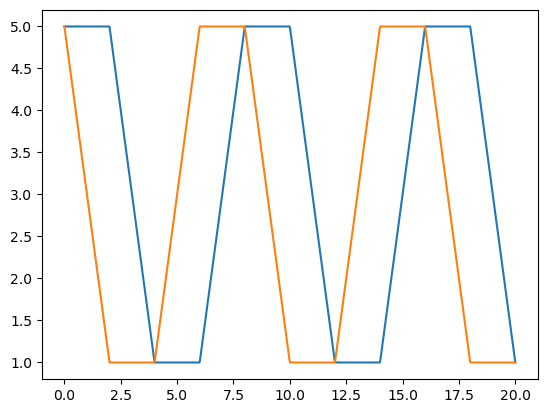

In [1]:
import matplotlib.pyplot as plt
import numpy as np

t0 = 2

def k(t):
    rem = t % t0
    phase = (t // t0) % 4
    
    conditions = [
        phase == 0,
        phase == 1,
        phase == 2,
        phase == 3
    ]

    choices = [
        5,
        5 - 2 * rem,
        1,
        1 + 2 * rem
    ]

    return np.select(conditions, choices, default = np.nan)

def T(t):
    rem = t % t0
    phase = (t // t0) % 4

    conditions = [
        phase == 0,
        phase == 1,
        phase == 2,
        phase == 3
    ]

    choices = [
        5 - 2 * rem,
        1,
        1 + 2 * rem,
        5
    ]

    return np.select(conditions, choices, default = np.nan)

t = np.linspace(0,20,800)
res = np.empty_like(t)
res2 = np.empty_like(t)
for i in range(len(t)):
    res[i] = k(t[i])
    res2[i] = T(t[i])
plt.plot(t,res)
plt.plot(t,res2)

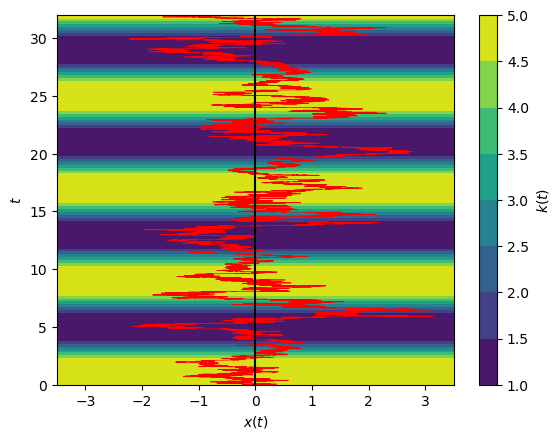

In [2]:
from LSolver import SimulationConfig, overdamped

def beta(t):
    return 1/T(t)
gma = 2.0

cfg = SimulationConfig(
    gamma = gma,
    F_func = lambda t,x,y: -k(t)*x,
    Tx_func = lambda t,x,y: T(t),
    Ty_func = lambda t,x,y: T(t),
    t_max = 32.0,
    dt = 0.001
)

fig, ax = plt.subplots(1,1)

[X, Y] = np.meshgrid(np.linspace(-3.5,3.5,150),np.linspace(0,32,150))
Z = k(Y)

cs = ax.contourf(X,Y,Z)

rng = np.random.default_rng(seed = 42)

data = overdamped(cfg, rng = rng)[0]

ax.set(xlabel = r"$x(t)$", ylabel = r"$t$")
ax.plot(data, cfg.t_array, color = "red", linewidth=0.5)
ax.plot([0,0],[0,32], color="black")
fig.colorbar(cs, label = r"$k(t)$")

In [ ]:
Qt = k(t) * data